# ============================================
INSTACART REORDER PREDICTION PROJECT
# ============================================


In [28]:
# Core libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

# Display full columns in outputs
pd.set_option('display.max_columns', None)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [29]:
# Load order-level information
orders = pd.read_csv(
    "/Users/balakrishnamupparaju/Downloads/archive-4/orders.csv",
    usecols=["order_id", "user_id", "days_since_prior_order"],
    dtype={
        "order_id": "int32",
        "user_id": "int32",
        "days_since_prior_order": "float32"
    }
)

# Load product-level reorder information
order_products = pd.read_csv(
    "/Users/balakrishnamupparaju/Downloads/archive-4/order_products__prior.csv",
    usecols=["order_id", "product_id", "reordered"],
    dtype={
        "order_id": "int32",
        "product_id": "int32",
        "reordered": "int8"
    }
)

print("Orders shape:", orders.shape)
print("Order products shape:", order_products.shape)

Orders shape: (3421083, 3)
Order products shape: (32434489, 3)


In [30]:
# Randomly sample 6% of orders
orders_sample = orders.sample(frac=0.06, random_state=42)

# Keep only matching order products
order_products_sample = order_products[
    order_products["order_id"].isin(orders_sample["order_id"])
]

print("Sampled dataset size:", order_products_sample.shape)

Sampled dataset size: (1951471, 3)


In [31]:
# Combine order-level and product-level data
data = order_products_sample.merge(orders_sample, on="order_id")

print("Merged dataset shape:", data.shape)

# Fill missing days_since_prior_order with 0 (first orders)
data["days_since_prior_order"] = data["days_since_prior_order"].fillna(0)

Merged dataset shape: (1951471, 5)


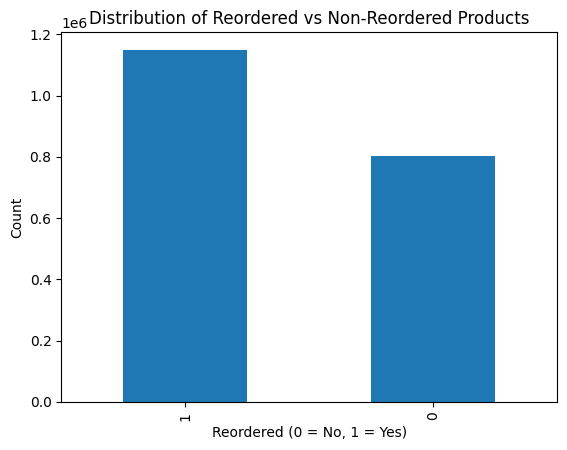

reordered
1    58.892804
0    41.107196
Name: proportion, dtype: float64


In [42]:
plt.figure()
data["reordered"].value_counts().plot(kind="bar")
plt.title("Distribution of Reordered vs Non-Reordered Products")
plt.xlabel("Reordered (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.savefig("Distribution_of_Reordered_vs_Non-Reordered_Products.png")
plt.show()

print(data["reordered"].value_counts(normalize=True) * 100)

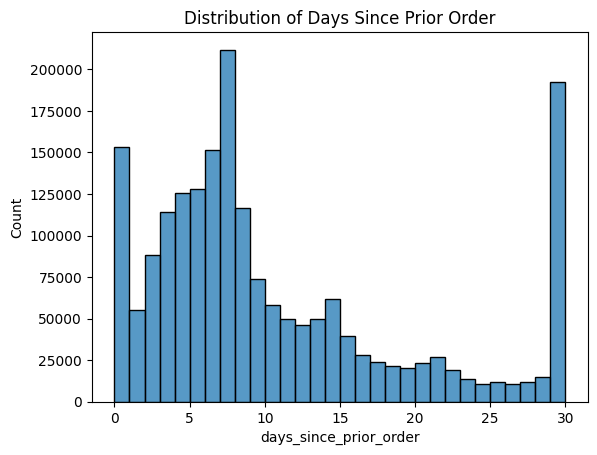

In [43]:
plt.figure()
sns.histplot(data["days_since_prior_order"], bins=30)
plt.title("Distribution of Days Since Prior Order")
plt.savefig("Distribution_of_Days_Since_Prior_Order.png")
plt.show()

In [34]:
# Aggregate historical behavior at user-product level
user_product = data.groupby(['user_id', 'product_id']).agg(
    total_purchases=('reordered', 'count'),
    avg_days_between=('days_since_prior_order', 'mean'),
    total_reorders=('reordered', 'sum')
).reset_index()

# Define target: whether product was reordered at least once
user_product['target'] = np.where(user_product['total_reorders'] > 0, 1, 0)

# DROP total_reorders to prevent leakage
user_product = user_product.drop(columns=['total_reorders'])

print("Final modeling dataset shape:", user_product.shape)

Final modeling dataset shape: (1668928, 5)


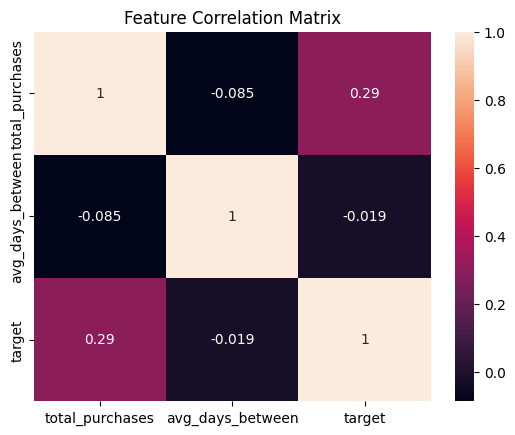

In [44]:
plt.figure()
sns.heatmap(user_product[['total_purchases','avg_days_between','target']].corr(), annot=True)
plt.title("Feature Correlation Matrix")
plt.savefig("Feature_Correlation_Matrix.png")
plt.show()

In [36]:
X = user_product[['total_purchases', 'avg_days_between']]
y = user_product['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [37]:
log_model = LogisticRegression(max_iter=500)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:,1]

print("Logistic Regression Performance")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))

Logistic Regression Performance
Accuracy: 0.5740324639140048
Precision: 1.0
Recall: 0.22936863823436954
F1 Score: 0.3731486733935085
ROC-AUC: 0.6425346297270192


In [38]:
rf_model = RandomForestClassifier(n_estimators=50, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

print("\nRandom Forest Performance")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))


Random Forest Performance
Accuracy: 0.6363678125106106
Precision: 0.6242429013803601
Recall: 0.8595235428236935
F1 Score: 0.7232290125887223
ROC-AUC: 0.7030910644804966


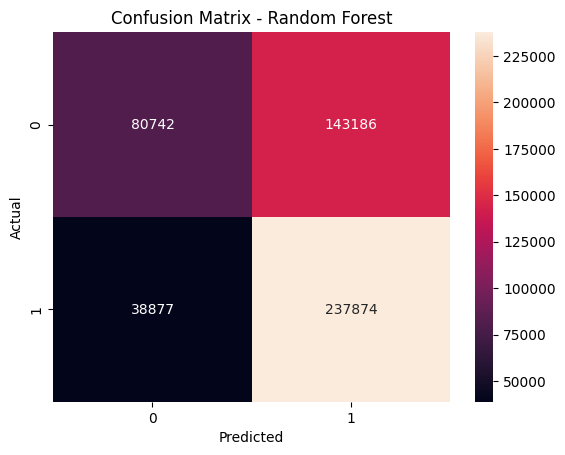

In [46]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("Confusion_Matrix_Random_Forest.png")
plt.show()

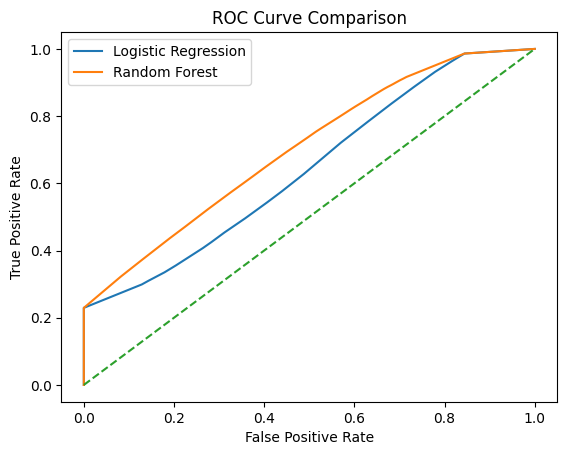

In [47]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure()
plt.plot(fpr_log, tpr_log, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.savefig("ROC_Curve_Comparison.png")
plt.show()
